In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
arquivo = "/content/amostra_chargegrid.xlsx"

df = pd.read_excel(arquivo)

print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

display(df.head())

Quantidade de linhas: 120
Quantidade de colunas: 8


,country,iso_code,year,population,gdp,renewables_share_energy,faixa_gdp,faixa_renovavel
0,Azerbaijan,AZE,2006,8763353,87026458624,4.366,Baixo PIB,Baixa
1,Czechia,CZE,1974,9960863,104186945536,0.950,Baixo PIB,Baixa
2,Netherlands,NLD,2018,17286042,818056003584,5.750,Baixo PIB,Baixa
3,Switzerland,CHE,2002,7276479,333238534144,29.157,Baixo PIB,Baixa
4,Bulgaria,BGR,1975,8860971,81059299328,2.734,Baixo PIB,Baixa


In [4]:
print("Tipos das variáveis:")
print(df.dtypes)

print("Valores ausentes:")
print(df.isnull().sum())

print("Estatísticas descritivas:")
display(df.describe())

Tipos das variáveis:
country                     object
iso_code                    object
year                         int64
population                   int64
gdp                          int64
renewables_share_energy    float64
faixa_gdp                   object
faixa_renovavel             object
dtype: object
Valores ausentes:
country                    0
iso_code                   4
year                       0
population                 0
gdp                        0
renewables_share_energy    0
faixa_gdp                  0
faixa_renovavel            1
dtype: int64
Estatísticas descritivas:


,year,population,gdp,renewables_share_energy
count,120.000000,1.200000e+02,1.200000e+02,120.000000
mean,1996.216667,7.563434e+07,7.025263e+11,9.741883
std,15.429527,1.629848e+08,1.051961e+12,12.047811
min,1965.000000,3.657870e+05,1.000032e+10,0.000000
25%,1984.000000,1.012171e+07,1.301510e+11,1.338500
50%,1997.500000,2.477760e+07,3.279802e+11,4.308500
75%,2009.250000,7.196298e+07,7.159175e+11,13.952250
max,2018.000000,1.338636e+09,7.767449e+12,70.526000


In [6]:

# EXERCÍCIO 01
# PROBABILIDADE DE VALORES ACIMA DA MEDIANA
# Variável selecionada: renewables_share_energy

print("="*60)
print("EXERCÍCIO 01 - PROBABILIDADE ACIMA DA MEDIANA")
print("="*60)


# Seleção da variável
variavel = df["renewables_share_energy"].dropna()


# Cálculo da média, desvio-padrão e mediana

media = variavel.mean()
desvio_padrao = variavel.std()

mediana = variavel.median()


print(f"\nVariável analisada: renewables_share_energy")
print(f"Média: {media:.4f}")
print(f"Desvio-padrão: {desvio_padrao:.4f}")
print(f"Mediana: {mediana:.4f}")


# Cálculo da probabilidade

# Assumindo que a variável segue uma distribuição Normal,
# calculamos P(X > mediana).

prob_abaixo_mediana = norm.cdf(
    mediana,
    loc=media,
    scale=desvio_padrao
)

prob_acima_mediana = 1 - prob_abaixo_mediana


print(f"\nProbabilidade de X <= mediana: "
      f"{prob_abaixo_mediana:.4f}")

print(f"Probabilidade de X > mediana: "
      f"{prob_acima_mediana:.4f}")

print(f"Probabilidade em porcentagem: "
      f"{prob_acima_mediana * 100:.2f}%")


# Classificação do evento

if prob_acima_mediana < 0.05:
    classificacao = "Raro"
elif prob_acima_mediana < 0.25:
    classificacao = "Pouco provável"
elif prob_acima_mediana < 0.75:
    classificacao = "Provável"
else:
    classificacao = "Quase certo"


print(f"Classificação do evento: {classificacao}")


EXERCÍCIO 01 - PROBABILIDADE ACIMA DA MEDIANA

Variável analisada: renewables_share_energy
Média: 9.7419
Desvio-padrão: 12.0478
Mediana: 4.3085

Probabilidade de X <= mediana: 0.3260
Probabilidade de X > mediana: 0.6740
Probabilidade em porcentagem: 67.40%
Classificação do evento: Provável


EXERCÍCIO 02 - PROBABILIDADE NO INTERVALO MÉDIA ± 2s

Média: 9.7419
Desvio-padrão: 12.0478

Limite inferior:
média - 2 × desvio-padrão = -14.3537

Limite superior:
média + 2 × desvio-padrão = 33.8375

Probabilidade entre os limites: 0.9545
Probabilidade em porcentagem: 95.45%
Classificação do evento: Quase certo


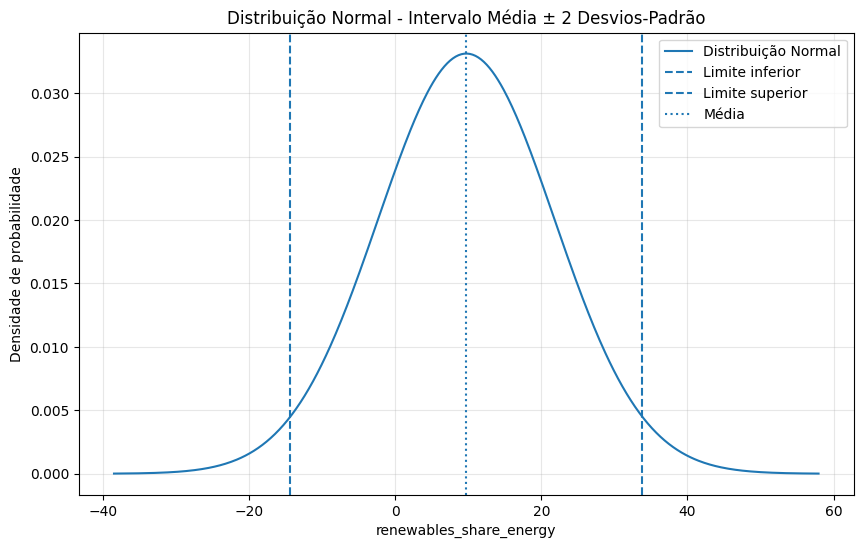

In [7]:
# EXERCÍCIO 02
# PROBABILIDADE NO INTERVALO MÉDIA ± 2 DESVIOS-PADRÃO

print("="*60)
print("EXERCÍCIO 02 - PROBABILIDADE NO INTERVALO MÉDIA ± 2s")
print("="*60)



# Cálculo dos limites do intervalo

limite_inferior = media - 2 * desvio_padrao
limite_superior = media + 2 * desvio_padrao


print(f"\nMédia: {media:.4f}")
print(f"Desvio-padrão: {desvio_padrao:.4f}")

print(f"\nLimite inferior:")
print(f"média - 2 × desvio-padrão = {limite_inferior:.4f}")

print(f"\nLimite superior:")
print(f"média + 2 × desvio-padrão = {limite_superior:.4f}")



# Cálculo da probabilidade
prob_inferior = norm.cdf(
    limite_inferior,
    loc=media,
    scale=desvio_padrao
)

prob_superior = norm.cdf(
    limite_superior,
    loc=media,
    scale=desvio_padrao
)

prob_intervalo = prob_superior - prob_inferior


print(f"\nProbabilidade entre os limites: "
      f"{prob_intervalo:.4f}")

print(f"Probabilidade em porcentagem: "
      f"{prob_intervalo * 100:.2f}%")



# Classificação do evento

if prob_intervalo < 0.05:
    classificacao_intervalo = "Raro"
elif prob_intervalo < 0.25:
    classificacao_intervalo = "Pouco provável"
elif prob_intervalo < 0.75:
    classificacao_intervalo = "Provável"
else:
    classificacao_intervalo = "Quase certo"


print(f"Classificação do evento: "
      f"{classificacao_intervalo}")



# GRÁFICO DA DISTRIBUIÇÃO NORMAL - EXERCÍCIO 02

x = np.linspace(
    media - 4 * desvio_padrao,
    media + 4 * desvio_padrao,
    500
)

y = norm.pdf(
    x,
    loc=media,
    scale=desvio_padrao
)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    y,
    label="Distribuição Normal"
)

plt.axvline(
    limite_inferior,
    linestyle="--",
    label="Limite inferior"
)

plt.axvline(
    limite_superior,
    linestyle="--",
    label="Limite superior"
)

plt.axvline(
    media,
    linestyle=":",
    label="Média"
)

plt.title(
    "Distribuição Normal - Intervalo Média ± 2 Desvios-Padrão"
)

plt.xlabel("renewables_share_energy")
plt.ylabel("Densidade de probabilidade")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [8]:
# EXERCÍCIO 03
# MODELAGEM COM REGRESSÃO LINEAR

# Variável independente (X): population
# Variável dependente (Y): gdp

print("="*60)
print("EXERCÍCIO 03 - REGRESSÃO LINEAR")
print("="*60)



# Preparação dos dados
# população para milhões de habitantes
# PIB para bilhões

df_reg = df[["population", "gdp"]].dropna().copy()

df_reg["population_milhoes"] = (
    df_reg["population"] / 1_000_000
)

df_reg["gdp_bilhoes"] = (
    df_reg["gdp"] / 1_000_000_000
)


# Variável independente X
X = df_reg[["population_milhoes"]]

# Variável dependente Y
y = df_reg["gdp_bilhoes"]



# Criação e treinamento do modelo

modelo = LinearRegression()

modelo.fit(X, y)



# Coeficientes do modelo

coef_angular = modelo.coef_[0]
intercepto = modelo.intercept_


print("\nCoeficientes do modelo:")
print(f"Coeficiente angular (β1): {coef_angular:.4f}")
print(f"Intercepto (β0): {intercepto:.4f}")



# Equação da regressão

print("\nEquação da regressão linear:")

print(
    f"PIB (bilhões) = "
    f"{intercepto:.4f} + "
    f"{coef_angular:.4f} × População (milhões)"
)



# Previsões

y_pred = modelo.predict(X)


# Avaliação do modelo

r2 = r2_score(y, y_pred)

rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)


print("\nAvaliação do modelo:")
print(f"R² = {r2:.4f}")
print(f"RMSE = {rmse:.4f} bilhões")


EXERCÍCIO 03 - REGRESSÃO LINEAR

Coeficientes do modelo:
Coeficiente angular (β1): 4.2579
Intercepto (β0): 380.4850

Equação da regressão linear:
PIB (bilhões) = 380.4850 + 4.2579 × População (milhões)

Avaliação do modelo:
R² = 0.4352
RMSE = 787.2873 bilhões


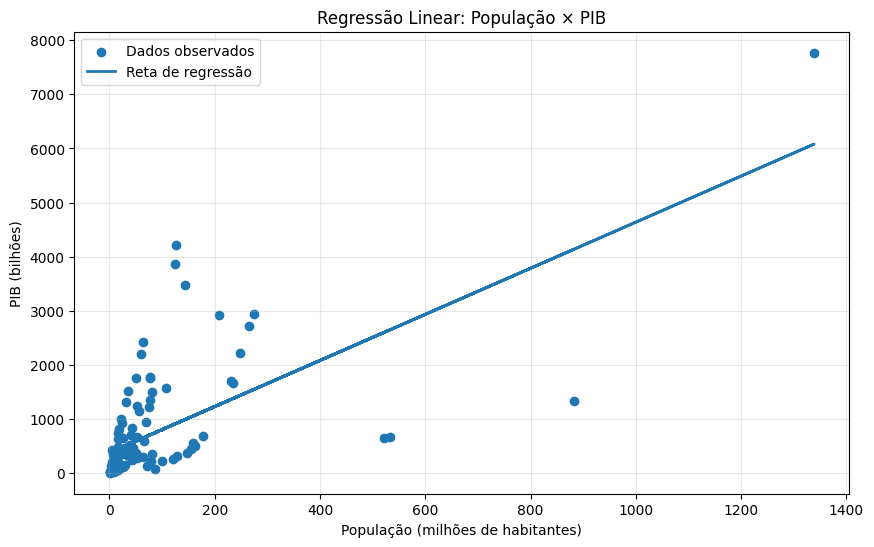

In [9]:
# GRÁFICO DA REGRESSÃO LINEAR

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    label="Dados observados"
)

plt.plot(
    X,
    y_pred,
    linewidth=2,
    label="Reta de regressão"
)

plt.title(
    "Regressão Linear: População × PIB"
)

plt.xlabel(
    "População (milhões de habitantes)"
)

plt.ylabel(
    "PIB (bilhões)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [10]:
print("="*60)
print("RESUMO DOS RESULTADOS")
print("="*60)

print(f"""
Variável utilizada nos exercícios de probabilidade:
renewables_share_energy

Mediana:
{mediana:.4f}

Probabilidade de valores acima da mediana:
{prob_acima_mediana * 100:.2f}%

Classificação:
{classificacao}

Intervalo Média ± 2 desvios-padrão:
[{limite_inferior:.4f}, {limite_superior:.4f}]

Probabilidade dentro do intervalo:
{prob_intervalo * 100:.2f}%

Classificação:
{classificacao_intervalo}

Regressão Linear:
PIB (bilhões) = {intercepto:.4f} +
{coef_angular:.4f} × População (milhões)

R²:
{r2:.4f}
""")

RESUMO DOS RESULTADOS

Variável utilizada nos exercícios de probabilidade:
renewables_share_energy

Mediana:
4.3085

Probabilidade de valores acima da mediana:
67.40%

Classificação:
Provável

Intervalo Média ± 2 desvios-padrão:
[-14.3537, 33.8375]

Probabilidade dentro do intervalo:
95.45%

Classificação:
Quase certo

Regressão Linear:
PIB (bilhões) = 380.4850 +
4.2579 × População (milhões)

R²:
0.4352



-  Exercício 01: considerando renewables_share_energy como uma variável aleatória com distribuição Normal, a mediana observada na amostra é 4,3085. Utilizando a média e o desvio-padrão da amostra, a probabilidade estimada de um valor ser superior à mediana é de aproximadamente 67,40%. De acordo com a classificação adotada, o evento é provável.

- Exercício 02: a média é 9,7419 e o desvio-padrão é 12,0478. Portanto, o intervalo definido por média ± 2 desvios-padrão é aproximadamente [-14,3537; 33,8375]. Sob a hipótese de distribuição Normal, a probabilidade de uma observação pertencer a esse intervalo é de 95,45%, sendo classificada como quase certo. O limite inferior negativo é matematicamente possível no modelo Normal, embora renewables_share_energy não possa assumir valores negativos na realidade; isso é uma limitação da hipótese de Normalidade que vale mencionar.

- Exercício 03: foi utilizada a população como variável independente e o PIB como variável dependente. O modelo estimado foi:

$$ PIB = 380,4850 + 4,2579 \times População $$

- onde PIB está em bilhões e população em milhões. Assim, no modelo ajustado, um aumento de 1 milhão de habitantes está associado a um aumento estimado de aproximadamente 4,26 bilhões no PIB. O coeficiente de determinação R² = 0,4352 indica que aproximadamente 43,52% da variabilidade observada no PIB é explicada pela população nesse modelo linear. O restante está relacionado a outros fatores não incluídos no modelo.

- Observação importante: essa última interpretação é de associação estatística, não significa que o aumento da população, isoladamente, cause o aumento do PIB.
